In [1]:
import pandas as pd

import h2o
from h2o.automl import H2OAutoML
h2o.init()


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) 64-Bit Server VM (build 25.431-b10, mixed mode)
  Starting server from C:\Users\jake\AppData\Roaming\Python\Python312\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\jake\AppData\Local\Temp\tmp5vux5kf4
  JVM stdout: C:\Users\jake\AppData\Local\Temp\tmp5vux5kf4\h2o_jake_started_from_python.out
  JVM stderr: C:\Users\jake\AppData\Local\Temp\tmp5vux5kf4\h2o_jake_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,America/Los_Angeles
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,1 month and 29 days
H2O_cluster_name:,H2O_from_python_jake_eda1bv
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.076 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [ ]:


def process_manual_labels_df(filepath):
    """Loads, cleans, and transforms the manual labels DataFrame. """
    df = pd.read_csv(filepath, sep='\t', index_col=0, low_memory=False) 
    df = df.reset_index()

    # Add string-based features
    df['reddit_key_len'] = df['reddit_key'].str.len()
    df['reddit_key_toks'] = df['reddit_key'].str.count(' ')
    df['ytmusic_key_len'] = df['ytmusic_key'].str.len()
    df['ytmusic_key_toks'] = df['ytmusic_key'].str.count(' ')
    df['key_len_diff'] = (df['reddit_key_len'] - df['ytmusic_key_len']).abs()

    num_cols = [
        'match_score_token_set_ratio', 'match_score_token_sort_ratio',
        'reddit_key_len', 'ytmusic_key_len', 'key_len_diff',
        'reddit_key_toks', 'ytmusic_key_toks'
    ]
    cat_cols = ['manual_label', 'reddit_sub']

    # Convert data types
    df[num_cols] = df[num_cols].apply(pd.to_numeric)
    df[cat_cols] = df[cat_cols].astype('category')

    return df[num_cols + cat_cols]


filepath = 'logs/ytmusic/reddit_all_manual_labels.tsv'
print(f"loaded matched dataset with shape: {df.shape}")

df = process_manual_labels_df(filepath)
df = df[df['manual_label'] != 'no-match']
print(f"graded_matches_filtered shape after removing 'no-match': {df.shape}")

# Replace 'manual_label' values with boolean True/False
df['manual_label'] = df['manual_label'] == 'passed-match'
print(df['manual_label'].value_counts())

print(df.info())
# print(df.head())


loaded matched dataset with shape: (82964, 9)
graded_matches_filtered shape after removing 'no-match': (82964, 9)
manual_label
True     54473
False    28491
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 82964 entries, 0 to 84044
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   match_score_token_set_ratio   82886 non-null  float64 
 1   match_score_token_sort_ratio  82886 non-null  float64 
 2   reddit_key_len                82934 non-null  float64 
 3   ytmusic_key_len               82884 non-null  float64 
 4   key_len_diff                  82880 non-null  float64 
 5   reddit_key_toks               82934 non-null  float64 
 6   ytmusic_key_toks              82884 non-null  float64 
 7   manual_label                  82964 non-null  bool    
 8   reddit_sub                    82964 non-null  category
dtypes: bool(1), category(1), float64(7)
memory usage:

In [18]:
%%time
SEED=1
MAX_MODELS = 50
MAX_TRAIN_TIME_HR = 0.5
TRAIN_SPLIT=0.8
LABEL_COL = 'manual_label'
VERBOSITY='info'

aml = H2OAutoML(
  balance_classes=True,
  seed=SEED, max_models =MAX_MODELS, 
  max_runtime_secs=int(MAX_TRAIN_TIME_HR*60*60),
)

train, test = h2o.H2OFrame(df).split_frame(
  ratios=[TRAIN_SPLIT], seed=SEED
)


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
CPU times: total: 734 ms
Wall time: 1.4 s


In [20]:
%%time
aml.train(training_frame=train, y=LABEL_COL)

AutoML progress: |


22:32:45.233: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
CPU times: total: 6 s
Wall time: 30min 2s


Model Details
=============
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_2_AutoML_3_20241231_223245


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    84                 84                          161137                 7            7            7             65            127           108.94

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.026006761135369937
RMSE: 0.1612661189939472
LogLoss: 0.09264925971013883
Mean Per-Class Error: 0.030485392106978513
AUC: 0.995881191250774
AUCPR: 0.9961170603058218
Gini: 0.991762382501548

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.6211671272889427
       False    True    Error    Rate
-----  -------  ------  -------  ----------------
False  42145    1367    0.0314   (1367.0/43512.0)
True   1288     42293   0.0296   (1288.0/43581.0)
Total  43433    43660   0.0305   (2655.0/87093.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.621167     0.969567  155
max f2                       0.341581     0.975579  234
max f0point5                 0.83191      0.977155  94
max accuracy                 0.621167     0.969515  155
max precision                0.999516     1         0
max recall                   0.00998538   1         385
max specificity              0.999516     1         0
max absolute_mcc             0.621167     0.939032  155
max min_per_class_accuracy   0.630176     0.969299  152
max mean_per_class_accuracy  0.621167     0.969515  155
max tns                      0.999516     43512     0
max fns                      0.999516     31622     0
max fps                      0.00253527   43512     399
max tps                      0.00998538   43581     385
max tnr                      0.999516     1         0
max fnr                      0.999516     0.725591  0
max fpr                      0.00253527   1         399
max tpr                      0.00998538   1         385

Gains/Lift Table: Avg response rate: 50.04 %, avg score: 52.29 %
group    cumulative_data_fraction    lower_threshold    lift        cumulative_lift    response_rate    score       cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ----------  -----------------  ---------------  ----------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100238                   0.999634           1.99842     1.99842            1                0.999663    1                           0.999663            0.0200317       0.0200317                  99.8417   99.8417            0.0200317
2        0.0201279                   0.999603           1.99842     1.99842            1                0.999614    1                           0.999638            0.0201923       0.040224                   99.8417   99.8417            0.040224
3        0.0300483                   0.999589           1.99842     1.99842            1                0.999594    1                           0.999624            0.0198252       0.0600491                  99.8417   99.8417            0.0600491
4        0.0400032                   0.999582           1.99842     1.99842            1                0.999586    1                           0.999614            0.019894        0.0799431                  99.8417   99.8417            0.0799431
5        0.0508307                   0.999565           1.99842     1.99842            1        

In [22]:
lb = aml.leaderboard
lb.head(rows=lb.nrows)

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
GBM_2_AutoML_3_20241231_223245,0.989819,0.123092,0.994664,0.0555523,0.190032,0.0361123
GBM_1_AutoML_3_20241231_223245,0.989818,0.122819,0.994662,0.0569668,0.190163,0.0361618
GBM_5_AutoML_3_20241231_223245,0.989806,0.122619,0.994631,0.0587855,0.189608,0.035951
GBM_3_AutoML_3_20241231_223245,0.989758,0.12398,0.994604,0.0588188,0.190491,0.036287
GBM_grid_1_AutoML_3_20241231_223245_model_3,0.989756,0.122665,0.994634,0.0543258,0.189653,0.0359682
GBM_grid_1_AutoML_3_20241231_223245_model_16,0.989748,0.12267,0.994603,0.056255,0.190011,0.0361042
GBM_grid_1_AutoML_3_20241231_223245_model_6,0.989686,0.123397,0.994613,0.0551983,0.189748,0.0360043
GBM_grid_1_AutoML_3_20241231_223245_model_9,0.989678,0.123395,0.994583,0.0537786,0.18993,0.0360736
GBM_grid_1_AutoML_3_20241231_223245_model_2,0.989641,0.123193,0.994528,0.0585478,0.190056,0.0361212
GBM_grid_1_AutoML_3_20241231_223245_model_12,0.989581,0.124762,0.994508,0.0569146,0.190853,0.0364249


In [23]:
best_model = aml.get_best_model()
print(best_model)

Model Details
H2OGradientBoostingEstimator : Gradient Boosting Machine
Model Key: GBM_2_AutoML_3_20241231_223245


Model Summary: 
    number_of_trees    number_of_internal_trees    model_size_in_bytes    min_depth    max_depth    mean_depth    min_leaves    max_leaves    mean_leaves
--  -----------------  --------------------------  ---------------------  -----------  -----------  ------------  ------------  ------------  -------------
    84                 84                          161137                 7            7            7             65            127           108.94

ModelMetricsBinomial: gbm
** Reported on train data. **

MSE: 0.026006761135369937
RMSE: 0.1612661189939472
LogLoss: 0.09264925971013883
Mean Per-Class Error: 0.030485392106978513
AUC: 0.995881191250774
AUCPR: 0.9961170603058218
Gini: 0.991762382501548

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.6211671272889427
       False    True    Error    Rate
-----  -------  ------  -------  ------------

In [24]:
best_model.model_performance(test)


ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.036638005361229214
RMSE: 0.19141056752757726
LogLoss: 0.12434961065845854
Mean Per-Class Error: 0.053271382815643364
AUC: 0.989724991130603
AUCPR: 0.9945210363635827
Gini: 0.9794499822612059

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.571195233907251
       False    True    Error    Rate
-----  -------  ------  -------  ---------------
False  5382     392     0.0679   (392.0/5774.0)
True   421      10471   0.0387   (421.0/10892.0)
Total  5803     10863   0.0488   (813.0/16666.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.571195     0.962629  181
max f2                       0.189603     0.973758  286
max f0point5                 0.860454     0.970695  94
max accuracy                 0.571195     0.951218  181
max precision                0.999588     1         0
max recall                   0.00980959   1         386
max specificity              0.999588     1         0
max absolute_mcc             0.571195     0.892411  181
max min_per_class_accuracy   0.69454      0.948494  145
max mean_per_class_accuracy  0.776558     0.949815  121
max tns                      0.999588     5774      0
max fns                      0.999588     9617      0
max fps                      0.00260579   5774      399
max tps                      0.00980959   10892     386
max tnr                      0.999588     1         0
max fnr                      0.999588     0.882942  0
max fpr                      0.00260579   1         399
max tpr                      0.00980959   1         386

Gains/Lift Table: Avg response rate: 65.35 %, avg score: 65.92 %
group    cumulative_data_fraction    lower_threshold    lift       cumulative_lift    response_rate    score      cumulative_response_rate    cumulative_score    capture_rate    cumulative_capture_rate    gain      cumulative_gain    kolmogorov_smirnov
-------  --------------------------  -----------------  ---------  -----------------  ---------------  ---------  --------------------------  ------------------  --------------  -------------------------  --------  -----------------  --------------------
1        0.0100204                   0.999643           1.53011    1.53011            1                0.999668   1                           0.999668            0.0153324       0.0153324                  53.0114   53.0114            0.0153324
2        0.0200408                   0.999611           1.53011    1.53011            1                0.999626   1                           0.999647            0.0153324       0.0306647                  53.0114   53.0114            0.0306647
3        0.0301212                   0.999595           1.53011    1.53011            1                0.999602   1                           0.999632            0.0154242       0.0460889                  53.0114   53.0114            0.0460889
4        0.0402016                   0.999588           1.53011    1.53011            1                0.999591   1                           0.999622            0.0154242       0.061513                   53.0114   53.0114            0.061513
5        0.050162                    0.99958            1.53011    1.53011            1                0.999584   1                           0.999614            0.0152405       0.0767536                  53.0114   53.0114            0.0767536
6        0.100024                    0.999505           1.53011    1.53011            1                0.999541   1                           0.999578            0.0762945       0.153048                   53.0114   53.0114            0.153048
7        0.150066                    0.999453           1.53011    1.53011            1                0.999482   1                           0.999546            0.07657         0.229618                   53.0114   53.0114         

In [62]:


def process_manual_labels_df(filepath):
    """Loads, cleans, and transforms the manual labels DataFrame. """
    df = pd.read_csv(filepath, sep='\t', index_col=0, low_memory=False) 
    df = df.reset_index()

    # Add string-based features
    df['reddit_key_len'] = df['reddit_key'].str.len()
    df['reddit_key_toks'] = df['reddit_key'].str.count(' ')
    df['ytmusic_key_len'] = df['ytmusic_key'].str.len()
    df['ytmusic_key_toks'] = df['ytmusic_key'].str.count(' ')
    df['key_len_diff'] = (df['reddit_key_len'] - df['ytmusic_key_len']).abs()

    num_cols = [
        'match_score_token_set_ratio', 'match_score_token_sort_ratio',
        'reddit_key_len', 'ytmusic_key_len', 'key_len_diff',
        'reddit_key_toks', 'ytmusic_key_toks'
    ]
    cat_cols = ['manual_label', 'reddit_sub']

    # Convert data types
    df[num_cols] = df[num_cols].apply(pd.to_numeric)
    df[cat_cols] = df[cat_cols].astype('category')

    return df[num_cols + cat_cols]


filepath = 'logs/ytmusic/reddit_2024-new_ytmusic_scored_new_matches.tsv_2024-12-31.tsv'
print(f"loaded matched dataset with shape: {df.shape}")

df = process_manual_labels_df(filepath)
# df[df['manual_label']] = None
df = df.drop(columns=['manual_label', ]) # 'no-label_2024-12-31'
new = h2o.H2OFrame(df)
model_id = best_model.model_id
df_pred = best_model.predict(new).as_data_frame()

df = pd.read_csv(filepath, sep='\t', index_col=0, low_memory=False) 
print(df.shape, df_pred.shape)
df[f"proba_{model_id}"] = df_pred['True']
df[f"match_{model_id}"] = df_pred['predict']
filepath_graded = filepath.replace('new_matches.tsv', 'new_matches__model-graded')
df.to_csv(filepath_graded, sep='\t')


# df = df[df['manual_label'] != 'no-match']
# print(f"graded_matches_filtered shape after removing 'no-match': {df.shape}")

# # Replace 'manual_label' values with boolean True/False
# df['manual_label'] = df['manual_label'] == 'passed-match'
# print(df['manual_label'].value_counts())

# print(df.info())
# # print(df.head())
# train, test = h2o.H2OFrame(df).split_frame(
#   ratios=[TRAIN_SPLIT], seed=SEED
# )

loaded matched dataset with shape: (16664, 25)
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\jake\AppData\Roaming\Python\Python312\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset column 'reddit_sub' has levels not trained on: ["OldElectronicMusic", "RootsMusic", "Samplehunters", "altcountry", "baroque", "industrialmusic", "neopsychedelia"]
  warnings.warn(w)
C:\Users\jake\AppData\Roaming\Python\Python312\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


(16664, 23) (16664, 3)


<Axes: ylabel='Frequency'>

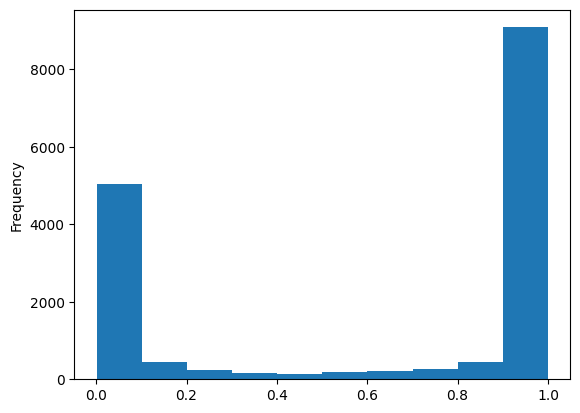

In [65]:
df['proba_GBM_2_AutoML_3_20241231_223245'].plot.hist()

In [ ]:
best_model.name

(16664, 8)

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%


C:\Users\jake\AppData\Roaming\Python\Python312\site-packages\h2o\job.py:81: UserWarning: Test/Validation dataset column 'reddit_sub' has levels not trained on: ["OldElectronicMusic", "RootsMusic", "Samplehunters", "altcountry", "baroque", "industrialmusic", "neopsychedelia"]
  warnings.warn(w)


In [54]:
df_pred['True']

True
0.998106
0.993096
0.999369
0.999428
0.999444
0.999408
0.99346
0.991305
0.99943
0.997386


# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
GBM_5_AutoML_3_20241231_223245,0.989809,0.123631,0.994581,0.0555427,0.191129,0.0365304,2018,0.029129,GBM
GBM_3_AutoML_3_20241231_223245,0.989743,0.12471,0.994507,0.0531034,0.191418,0.0366408,2252,0.033839,GBM
GBM_2_AutoML_3_20241231_223245,0.989725,0.12435,0.994521,0.0532714,0.191411,0.036638,2230,0.028565,GBM
GBM_1_AutoML_3_20241231_223245,0.989719,0.124087,0.994543,0.0544629,0.191605,0.0367123,3360,0.051025,GBM
GBM_grid_1_AutoML_3_20241231_223245_model_16,0.989648,0.123685,0.994469,0.0526944,0.191197,0.0365564,3363,0.054587,GBM
GBM_grid_1_AutoML_3_20241231_223245_model_6,0.98954,0.125264,0.994389,0.054707,0.191793,0.0367845,2050,0.025839,GBM
GBM_grid_1_AutoML_3_20241231_223245_model_3,0.989508,0.124371,0.994321,0.0525765,0.191612,0.0367152,2526,0.031165,GBM
GBM_grid_1_AutoML_3_20241231_223245_model_12,0.989507,0.125654,0.994262,0.0536115,0.191791,0.0367839,1796,0.021205,GBM
GBM_4_AutoML_3_20241231_223245,0.989425,0.128418,0.994326,0.0542344,0.19398,0.0376283,2358,0.030495,GBM
GBM_grid_1_AutoML_3_20241231_223245_model_2,0.989394,0.12571,0.994337,0.0562553,0.19253,0.0370678,2264,0.029224,GBM


# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## GBM_2_AutoML_3_20241231_223245

,False,True,Error,Rate
False,5382.0,392.0,0.0679,(392.0/5774.0)
True,421.0,10471.0,0.0387,(421.0/10892.0)
Total,5803.0,10863.0,0.0488,(813.0/16666.0)


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

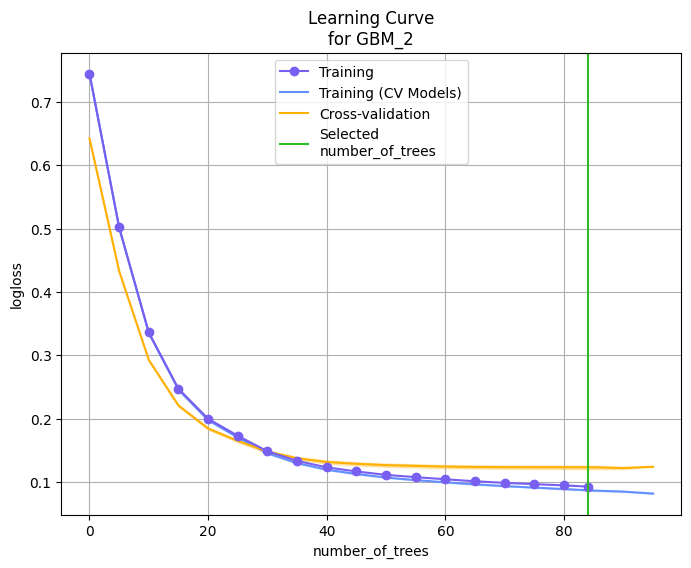

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

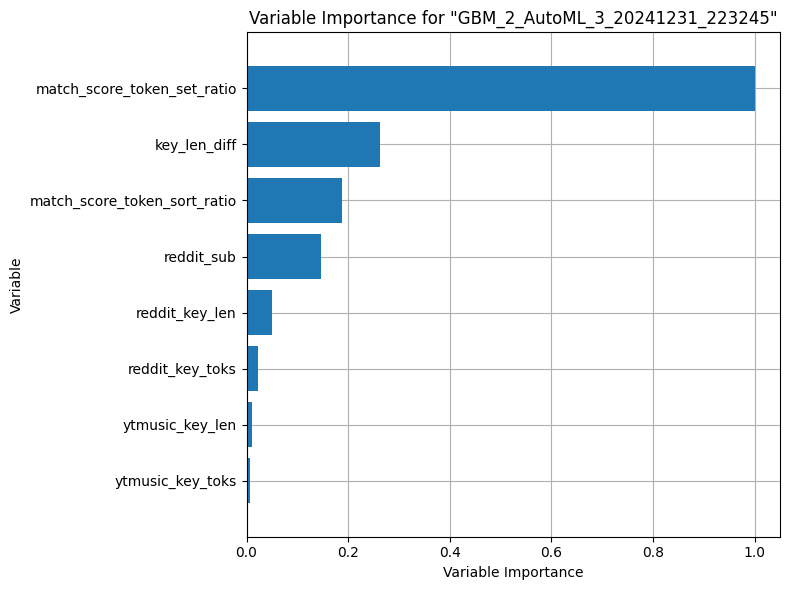

# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

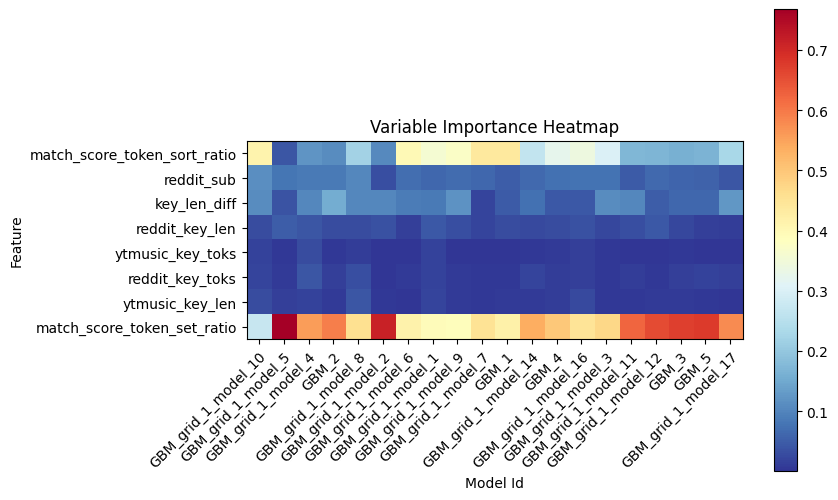

# Model Correlation

> This plot shows the correlation between the predictions of the models. For classification, frequency of identical predictions is used. By default, models are ordered by their similarity (as computed by hierarchical clustering). Interpretable models, such as GAM, GLM, and RuleFit are highlighted using red colored text.

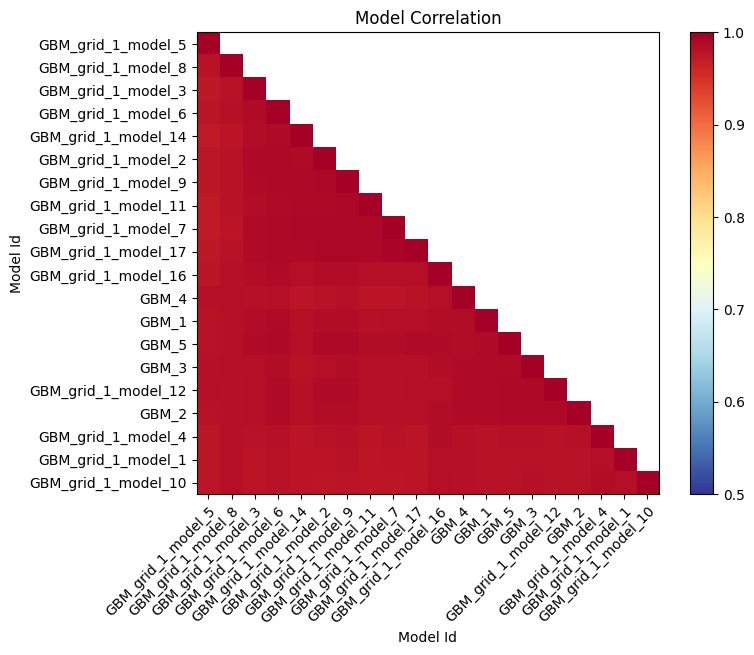

# SHAP Summary

> SHAP summary plot shows the contribution of the features for each instance (row of data). The sum of the feature contributions and the bias term is equal to the raw prediction of the model, i.e., prediction before applying inverse link function.

H2OResponseError: Server error java.lang.IllegalArgumentException:
  Error: Incorrect number of arguments; 'cols_py' expects 2 but was passed 3
  Request: POST /99/Rapids
    data: {'ast': "(tmp= py_473_sid_8468 (levels (tmp= py_472_sid_8468 (as.factor (cols_py py_471_sid_8468 np.str_('manual_label'))))))", 'session_id': '_sid_8468'}


In [25]:
explain_model = aml.explain(frame = test, figsize = (8,6))


## OLD

In [ ]:

import sklearn.metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from autosklearn.classification import AutoSklearnClassifier
from autosklearn.metrics import (accuracy,
                                 f1,
                                 roc_auc,
                                 precision,
                                 average_precision,
                                 recall,
                                 log_loss)

In [ ]:
y = df.pop('manual_label')
X = df.copy()
TEST_RATIO = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = TEST_RATIO, random_state=1, stratify=y)
print(f'Split {len(y)} entires into {len(y_train)} train and {len(y_test)} test ({round(TEST_RATIO*100)}% test)')



Below are some of the parameters used in AutoSklearnClassifier.

```
time_left_for_this_task: Limit the total training time (in seconds)

max_models_on_disc: Limit the number of models to keep

memory_limit: The amount of memory (in MB) which we want to utilize

resampling_strategy: holdout or different kinds of cross validation. Refer to this documentation: https://automl.github.io/auto-sklearn/master/api.html

ensemble_size: Number of models to include in the ensemble. Auto-Sklearn provides an option to create ensemble after the individual models are created by taking the top ensemble_size number of models in a weighted fashion.

metric: A metric which we want to optimize

scoring_function: One or more metrics which we want to evaluate the model on
```

Under the hood, Auto-Sklearn constructs a Scikit-Learn pipeline during each trial. A Scikit-Learn pipeline is used to assemble a series of steps that performs data processing, feature processing and an estimator (classifier or regressor). The fit function trigger the entire Auto-Sklearn constructing, fitting and evaluating multiple Scikit-Learn pipeline until the stopping criteria time_left_for_this_task is met.

In [9]:
skf = StratifiedKFold(n_splits=5)
  
clf = AutoSklearnClassifier(time_left_for_this_task=600,
                            max_models_on_disc=10,
                            memory_limit = 10240/2,
                            resampling_strategy=skf,
                            ensemble_size = 3,
                            metric = average_precision,
                            scoring_functions=[roc_auc, average_precision, accuracy, f1, precision, recall, log_loss])

clf.fit(X = X_train, y = y_train)



/usr/local/lib/python3.10/site-packages/autosklearn/data/target_validator.py:187: UserWarning: Fitting transformer with a pandas series which has the dtype category. Inverse transform may not be able preserve dtype when converting to np.ndarray
  warnings.warn(


[ERROR] [2023-01-03 01:38:20,721:Client-AutoML(1):5b450b1c-8b4a-11ed-bea6-aaea007e9178] (' Dummy prediction failed with run state StatusType.CRASHED and additional output: {\'error\': \'Result queue is empty\', \'exit_status\': "<class \'pynisher.limit_function_call.AnythingException\'>", \'subprocess_stdout\': \'\', \'subprocess_stderr\': \'Process pynisher function call:\\nTraceback (most recent call last):\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap\\n    self.run()\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 108, in run\\n    self._target(*self._args, **self._kwargs)\\n  File "/usr/local/lib/python3.10/site-packages/pynisher/limit_function_call.py", line 108, in subprocess_func\\n    resource.setrlimit(resource.RLIMIT_AS, (mem_in_b, mem_in_b))\\nValueError: current limit exceeds

ValueError: (' Dummy prediction failed with run state StatusType.CRASHED and additional output: {\'error\': \'Result queue is empty\', \'exit_status\': "<class \'pynisher.limit_function_call.AnythingException\'>", \'subprocess_stdout\': \'\', \'subprocess_stderr\': \'Process pynisher function call:\\nTraceback (most recent call last):\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap\\n    self.run()\\n  File "/usr/local/Cellar/python@3.10/3.10.9/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/process.py", line 108, in run\\n    self._target(*self._args, **self._kwargs)\\n  File "/usr/local/lib/python3.10/site-packages/pynisher/limit_function_call.py", line 108, in subprocess_func\\n    resource.setrlimit(resource.RLIMIT_AS, (mem_in_b, mem_in_b))\\nValueError: current limit exceeds maximum limit\\n\', \'exitcode\': 1, \'configuration_origin\': \'DUMMY\'}.'

In [ ]:
clf.leaderboard(detailed = True, ensemble_only=False)

In [ ]:
clf.get_models_with_weights()

In [6]:
clf.sprint_statistics()


AttributeError: 'AutoMLClassifier' object has no attribute 'runhistory_'

In [ ]:
clf.refit(X = X_train, y = y_train)
dump(clf, 'model.joblib')
clf = load('model.joblib')
y_probas = clf.predict_proba(X_test)
pos_label = 'yes'
y_proba = y_probas[:, clf.classes_.tolist().index(pos_label)]

In [33]:
# add len query, rsult, diff, num spaces

df['manual_label'] = df['manual_label'].astype('category').cat.codes.astype(int)
df['reddit_sub'] = df['reddit_sub'].astype('category').cat.codes.astype(int)

feature_cols = [
    'match_score_token_set_ratio', 'match_score_token_sort_ratio', 
    'reddit_key_len', 'ytmusic_key_len', 'key_len_diff', 
    'reddit_key_toks', 'ytmusic_key_toks'
] 
            
predict_col = 'manual_label' # convert to 1/0

dataset = df[feature_cols + [predict_col]].dropna()

In [34]:
dataset

,match_score_token_set_ratio,match_score_token_sort_ratio,reddit_key_len,ytmusic_key_len,key_len_diff,reddit_key_toks,ytmusic_key_toks,manual_label
0,100,82,7.0,12.0,5.0,0.0,2.0,0
1,100,80,10.0,17.0,7.0,1.0,3.0,0
2,100,37,7.0,36.0,29.0,0.0,6.0,0
3,100,37,53.0,13.0,40.0,10.0,2.0,0
4,100,37,8.0,40.0,32.0,0.0,6.0,0
...,...,...,...,...,...,...,...,...
56610,50.0,38.0,43.0,18.0,25.0,6.0,3.0,0
56611,30.0,30.0,93.0,31.0,62.0,15.0,6.0,0
56612,63.0,36.0,13.0,33.0,20.0,2.0,4.0,0
56613,62.0,0.5,20.0,26.0,6.0,3.0,4.0,0
